# 6. Does `R` grow with symmetry-**equivalent** orbitals?

Every number in this project so far rests on two models — square (`nb`=1) and FeAs (`nb`=2) — that
differ in β, band count, interaction **and** filling simultaneously. Notebook 05 is explicit about
the consequence: the mechanism is measured, the attribution is not. `R` = 1.04 on square and 3.04 on
FeAs is a gap with four candidate causes and no way to separate them.

This notebook is the sweep that separates them. Four design points at a **fixed β = 5**, each moving
as few axes as the model tree allows:

| point | what it is for |
|---|---|
| `square_b5_c4` | the **keystone** — square at *FeAs's* temperature, so the nb comparison is not also a β comparison |
| `fe_as` β=5 | reused from notebook 05's ladder, not re-run |
| `threeband_b5_c4` | the `nb`=3 point **and** the inequivalent-orbital control, in one run |
| `square_b5_c8` | the cluster axis — a genuine single-axis pair with `square_b5_c4` |

**Why `threeband` carries two questions at once.** Its d orbital is inequivalent to its two p
orbitals, while the two p orbitals are equivalent to each other. So a single run contains both a
band-pair block where the point group *does* permute bands (p–p′) and blocks where it cannot (d–d,
d–p). If the claim of TAKEAWAYS 4c is right — that the benefit comes from symmetry-**equivalent**
orbitals rather than from orbital count — those blocks must behave differently **within one model**,
with β, `U`, filling and geometry held exactly fixed. That is a far stronger control than a second
whole model would be.

Crucially, the band-equivalence classes are **derived from `P`**, never declared: two bands are
equivalent iff some symmetry orbit contains band-diagonal entries of both. Whether threeband really
has the structure claimed above is therefore something the run reports, not something we assert.

In [1]:
import sys, json
sys.path.insert(0, '.')
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 110
# Okabe-Ito, assigned per MODEL and never cycled: colour follows the entity, not its rank.
C  = {'square': '#0072B2', 'fe_as': '#D55E00', 'threeband': '#009E73'}
MK = {'square': 'o',       'fe_as': 's',       'threeband': 'D'}
INK, MUTED = '#222222', '#666666'

S    = json.load(open('../runs/model_sweep.json'))
ROWS = S['rows']
BY   = {r['label']: r for r in ROWS}
# The nb=2 point is the committed beta=5 rung of notebook 05's FeAs ladder -- reused, not re-run.
FE = [r for r in json.load(open('../runs/beta_ladder_fe_as.json'))['report']['rungs']
      if abs(r['beta'] - 5.0) < 1e-9][0]

for r in ROWS:
    print(f"{r['label']:<20} nb={r['nb']} nk={r['nk']:>3} |G|={r['n_ops']} "
          f"seeds={r['n_seeds']:>3}  R={r['R_full']['mean']:.4f} +/- {r['R_full']['sem']:.4f}")
print(f"{'fe_as_b5_c4 (ref)':<20} nb={FE['nb'] if 'nb' in FE else 2} nk=16 |G|=8 "
      f"seeds={FE['n_seeds']:>3}  R={FE['R_full']['mean']:.4f} +/- {FE['R_full']['sem']:.4f}")
viol = [v for r in ROWS for v in (r.get('seed_spacing_violations') or [])]
print('\nseed-spacing violations:', viol or 'none')

square_b5_c4         nb=1 nk= 16 |G|=8 seeds= 32  R=1.2619 +/- 0.0072
threeband_b5_c4      nb=3 nk= 16 |G|=8 seeds= 32  R=3.2380 +/- 0.0359
square_b5_c8         nb=1 nk= 64 |G|=8 seeds= 16  R=1.5006 +/- 0.0130
fe_as_b5_c4 (ref)    nb=2 nk=16 |G|=8 seeds= 32  R=2.9679 +/- 0.0592

seed-spacing violations: none


## The measured sweep

Everything below is read from `runs/model_sweep.json`, which `model_sweep.py build` produced by
verifying **every run's own HDF5 metadata against the declared design point** and raising on any
disagreement — so a run staged into the wrong directory is a hard error rather than a silent
contribution to an average.

In [2]:
print(S['report'])

=== model sweep: design points ===
  point                 nb  |G|   nk  seeds               R_full            R_nonnull           w_null              rho   <s>min
  ----------------------------------------------------------------------------------------------------------------------------------
  square_b5_c4           1    8   16     32    1.2619 +/- 0.0072    1.2619 +/- 0.0072 0.0000 +/- 0.0000 0.6623 +/- 0.0049    1.000
  threeband_b5_c4        3    8   16     32    3.2380 +/- 0.0359    2.5741 +/- 0.0254 0.2047 +/- 0.0018 0.1610 +/- 0.0037    0.539
  square_b5_c8           1    8   64     16    1.5006 +/- 0.0130    1.5006 +/- 0.0130 0.0000 +/- 0.0000 0.5309 +/- 0.0056    1.000

=== band-permutation content (is the band machinery live?) ===
  point                 nb  nonzero P  off-block    frac  orbits  mixing  nulls  perms  realized
  --------------------------------------------------------------------------------------------------------------
  square_b5_c4           1         5

## The `nb` trend — and why it is a trend, not a controlled axis

⚠️ **Read the caveat before the figure.** `nb` cannot be varied while holding "model" fixed: there is
no such thing as the same lattice with a different band count. The aggregator enforces the
one-axis-at-a-time rule mechanically (`axis_pairs` refuses to pair points that differ in more than
the named axis), and it emits **no pair for `nb`** for exactly this reason. The single-axis result in
this notebook is the *cluster* axis, where square 4×4 and 8×8 differ in `nk` and nothing else.

So the three points below are a **trend across models at fixed β**, which is strictly weaker than a
controlled axis. What makes it worth plotting anyway is that the one confound the earlier comparison
could not shed — temperature — is now held fixed by construction, and the *within-model* control on
the next figure carries the causal weight.

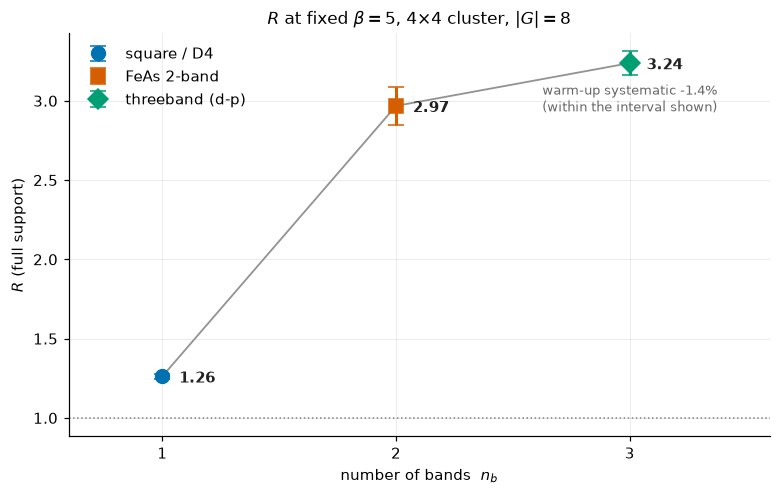

In [3]:
pts = [(BY['square_b5_c4'], 1, 'square', 'square / D4'),
       (FE,                    2, 'fe_as', 'FeAs 2-band'),
       (BY['threeband_b5_c4'], 3, 'threeband', 'threeband (d-p)')]

fig, ax = plt.subplots(figsize=(7.2, 4.6))
for r, nb, key, disp in pts:
    st = r['R_full']
    ax.errorbar(nb, st['mean'], yerr=[[st['mean'] - st['lo']], [st['hi'] - st['mean']]],
                fmt=MK[key], ms=9, lw=2, capsize=5, color=C[key], label=disp, zorder=3)
    ax.annotate(f"{st['mean']:.2f}", (nb, st['mean']), textcoords='offset points',
                xytext=(11, -4), color=INK, fontsize=10, fontweight='bold')
ax.plot([p[1] for p in pts], [p[0]['R_full']['mean'] for p in pts],
        '-', color=MUTED, lw=1.2, alpha=.7, zorder=1)

# The threeband point carries a warm-up systematic. It is SMALLER than the plotted 95% interval, so
# drawing it as a band would render it invisible and imply it does not exist -- it is stated instead.
sysd = {s['parent']: s for s in S.get('systematics', [])}.get('threeband_b5_c4')
if sysd and sysd.get('R_full'):
    v = sysd['R_full']
    ax.annotate(f"warm-up systematic {100 * v['frac']:+.1f}%\n(within the interval shown)",
                (3, BY['threeband_b5_c4']['R_full']['lo']), textcoords='offset points',
                xytext=(0, -24), color=MUTED, fontsize=8.5, ha='center')

ax.axhline(1.0, ls=':', c='0.5', lw=1)
ax.set(xlabel='number of bands  $n_b$', ylabel=r'$R$ (full support)', xticks=[1, 2, 3],
       xlim=(0.6, 3.6))
ax.set_title(r'$R$ at fixed $\beta=5$, 4$\times$4 cluster, $|G|=8$', fontsize=11)
ax.grid(alpha=.25, lw=.6)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
ax.legend(frameon=False, loc='upper left')
plt.tight_layout(); plt.show()

## The control that carries the causal weight

Now **inside one model**, with every other axis frozen. The equivalence-aware partition splits every
entry of threeband's `(b0, b1, k)` index space four ways:

- **diagonal, band-orbit 1** — the d–d block. `d` is alone in its equivalence class, so no group
  element maps it anywhere: symmetrization can only average it over k-orbits.
- **diagonal, band-orbit >1** — the p–p and p′–p′ blocks, which the group *can* interchange.
- **off-diagonal, inequivalent** — d–p. Off-diagonal, but between bands the group cannot relate.
- **off-diagonal, equivalent** — p–p′. Off-diagonal **and** band-permutable: the block where both
  effects are live at once.

If band **count** were what mattered, all four would improve together. If symmetry-**equivalence** is
what matters, the two `equivalent` classes must separate from the two `inequivalent` ones. The
harmonic reconstruction printed underneath is a self-check: the per-class `R_C` must recombine to the
aggregate `R` exactly, so a mis-specified partition shows up as a nonzero gap rather than as a
plausible-looking table.

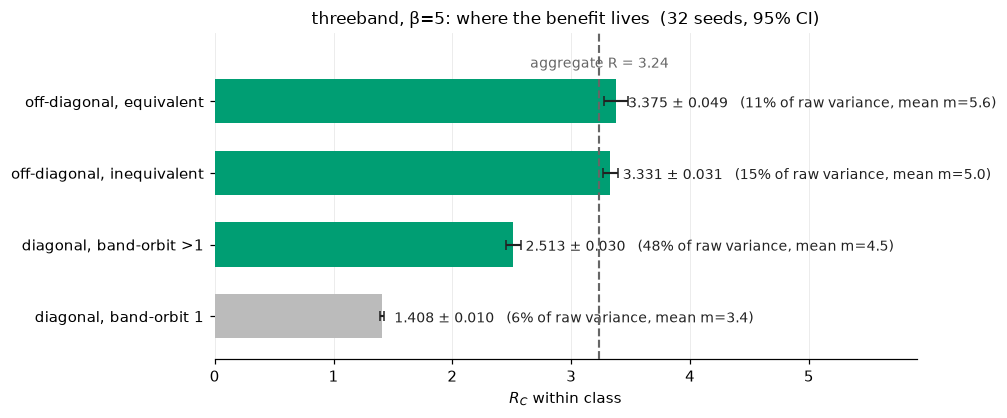

band-equivalence classes (derived from P, not declared): [[0], [1, 2]]
realized band permutations: ['012', '021']
partition self-check on the reference run: harmonic reconstruction 3.280685 vs aggregate 3.280685 (gap 4.44e-16)


In [4]:
tb = BY['threeband_b5_c4']
cs = tb['class_stats']['equivalence']
# Forced nulls have R_C = inf by construction (noise driven to exactly zero); they are reported in
# w_null, not on an axis that would have to be broken to hold them.
items = [(k, v) for k, v in cs.items() if v['R_C']]
items.sort(key=lambda kv: -kv[1]['R_C']['mean'])

fig, ax = plt.subplots(figsize=(9.0, 3.9))
ys = np.arange(len(items))[::-1]
# Greyscale by whether a band permutation can REACH the class, which is the distinction under test.
# Hue is reserved for model identity in the figure above; re-using it here would imply a link.
reach = {'diagonal, band-orbit 1': False}
cols = ['#BBBBBB' if reach.get(k, True) is False else '#009E73' for k, _ in items]
vals = [v['R_C']['mean'] for _, v in items]
errs = [[v['R_C']['mean'] - v['R_C']['lo'] for _, v in items],
        [v['R_C']['hi'] - v['R_C']['mean'] for _, v in items]]
ax.barh(ys, vals, color=cols, height=.62, zorder=2)
ax.errorbar(vals, ys, xerr=errs, fmt='none', ecolor=INK, elinewidth=1.4, capsize=3, zorder=4)
for y, (k, v), val in zip(ys, items, vals):
    ax.annotate(f"{val:.3f} ± {v['R_C']['sem']:.3f}   "
                f"({100 * v['w']['mean']:.0f}% of raw variance, mean m={v['mean_m']:.1f})",
                (val, y), textcoords='offset points', xytext=(8, -4), fontsize=9, color=INK)
agg = tb['R_full']['mean']
ax.axvline(agg, ls='--', color=MUTED, lw=1.4, zorder=3)
ax.annotate(f'aggregate R = {agg:.2f}', (agg, ys[0]), textcoords='offset points', xytext=(0, 22),
            fontsize=9, color=MUTED, ha='center')
ax.set(yticks=ys, yticklabels=[k for k, _ in items], xlabel=r'$R_C$ within class',
       xlim=(0, max(vals) * 1.75), ylim=(ys[-1] - .6, ys[0] + .95))
ax.set_title(f"threeband, β=5: where the benefit lives  ({tb['n_seeds']} seeds, 95% CI)",
             fontsize=11)
ax.grid(axis='x', alpha=.25, lw=.6)
for s in ('top', 'right', 'left'):
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

print('band-equivalence classes (derived from P, not declared):',
      tb['structure']['band_equivalence']['classes'])
print('realized band permutations:', sorted(tb['structure']['permutation']['permutations']))
eq1 = tb['by_class']['equivalence']
print(f"partition self-check on the reference run: harmonic reconstruction "
      f"{eq1['harmonic_reconstruction']:.6f} vs aggregate {eq1['aggregate_R']:.6f} "
      f"(gap {eq1['reconstruction_gap']:.2e})")

### The contrasts, with intervals

A prediction that survives only because nobody put an interval on it is not evidence. These are
differences between classes **within the one model**, so β, `U`, filling and geometry are held fixed
by construction, and the error is the scatter between seeds.

In [5]:
for c in S['class_contrasts']:
    if c['point'] != 'threeband_b5_c4':
        continue
    verdict = 'RESOLVED' if c['resolved'] else 'not resolved (interval spans zero)'
    print(f"{c['contrast']:<34} {c['a_mean']:.3f} - {c['b_mean']:.3f} = "
          f"{c['delta']:+.3f}  95% [{c['lo']:+.3f}, {c['hi']:+.3f}]   {verdict}")
print()
print('For reference, the single-band square point at the same beta:',
      f"R = {BY['square_b5_c4']['R_full']['mean']:.3f} "
      f"+/- {BY['square_b5_c4']['R_full']['sem']:.3f}, mean m = "
      f"{BY['square_b5_c4']['class_stats']['equivalence']['diagonal, band-orbit 1']['mean_m']:.2f}")

off-diagonal: inequiv - equiv      3.331 - 3.375 = -0.045  95% [-0.163, +0.074]   not resolved (interval spans zero)
diagonal: band-orbit >1 - 1        2.513 - 1.408 = +1.105  95% [+1.039, +1.170]   RESOLVED
off-diag equiv - diag orbit 1      3.375 - 1.408 = +1.967  95% [+1.864, +2.070]   RESOLVED

For reference, the single-band square point at the same beta: R = 1.262 +/- 0.007, mean m = 3.38


## Which ceiling binds

`r = m/[1+(m−1)ρ]` is squeezed between two ceilings: the orbit size `m`, and `1/ρ` set by how
mate-correlated the noise is. Whichever is smaller is what a practitioner is actually fighting, and
it prescribes different actions — chase colder physics when `ρ` binds, chase bigger orbits when `m`
does. This is the one-run diagnostic of TAKEAWAYS 3, evaluated across the sweep.

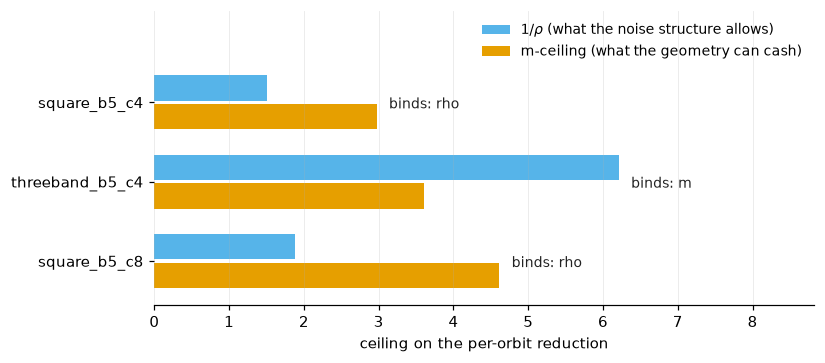

In [6]:
fig, ax = plt.subplots(figsize=(7.6, 3.4))
labs = [r['label'] for r in ROWS]
ys = np.arange(len(ROWS))[::-1]
w = .32   # < the .5 half-spacing, so the paired bars carry a visible gap rather than touching
ax.barh(ys + .18, [r['inv_rho'] for r in ROWS], height=w, color='#56B4E9',
        label=r'$1/\rho$ (what the noise structure allows)')
ax.barh(ys - .18, [r['m_ceiling'] for r in ROWS], height=w, color='#E69F00',
        label=r'm-ceiling (what the geometry can cash)')
for y, r in zip(ys, ROWS):
    ax.annotate(f"binds: {r['binding']}", (max(r['inv_rho'], r['m_ceiling']), y),
                textcoords='offset points', xytext=(8, -4), fontsize=9, color=INK)
ax.set(yticks=ys, yticklabels=labs, xlabel='ceiling on the per-orbit reduction')
# Headroom for the legend, which sits above the bars: the annotations own the right-hand margin.
ax.set_xlim(0, max(max(r['inv_rho'], r['m_ceiling']) for r in ROWS) * 1.42)
ax.set_ylim(ys[-1] - .55, ys[0] + 1.15)
ax.grid(axis='x', alpha=.25, lw=.6)
for s in ('top', 'right', 'left'):
    ax.spines[s].set_visible(False)
ax.legend(frameon=False, fontsize=9, loc='upper right', ncol=1)
plt.tight_layout(); plt.show()

## The systematic that must be quoted with the threeband number

threeband is run at **warm-up 8000**, not the project Convention's 200. That is not a preference: at
warm-up 200 the model's depth ladder *appears* to drift, which reads as an unconverged depth floor
but is actually an unthermalized chain (raising warm-up at fixed depth reproduces what 4× depth
bought). Square at the same β is flat in depth at warm-up 200, which is the control that makes this
specific to threeband's much larger expansion order.

What is **not** established is where warm-up converges. The sensitivity arm re-runs the same design
point at warm-up 2000 with its own disjoint seed range, so the residual dependence is measured rather
than assumed. It is reported as a **disclosed systematic**, not used as a correction.

In [7]:
for s in S.get('systematics', []):
    v = s['R_full']
    print(f"{s['arm']}  vs  {s['parent']}")
    print(f"  knob      : {s['knobs']}  {s['arm_knobs']} vs {s['parent_knobs']}")
    print(f"  seeds     : arm n={s['n_arm']}, parent n={s['n_parent']}")
    print(f"  R         : {v['arm']:.4f} (arm)  vs  {v['parent']:.4f} (parent)")
    print(f"  delta     : {v['delta']:+.4f}  95% [{v['lo']:+.4f}, {v['hi']:+.4f}]"
          f"  -> {100 * v['frac']:+.1f}% of R, resolved={v['resolved']}")
    print(f"  statistical error on the parent for comparison: "
          f"+/- {BY[s['parent']]['R_full']['sem']:.4f}")

threeband_b5_c4_w2000  vs  threeband_b5_c4
  knob      : ['warm_up_sweeps']  {'warm_up_sweeps': 2000} vs {'warm_up_sweeps': 8000}
  seeds     : arm n=8, parent n=32
  R         : 3.1939 (arm)  vs  3.2380 (parent)
  delta     : -0.0441  95% [-0.2269, +0.1388]  -> -1.4% of R, resolved=False
  statistical error on the parent for comparison: +/- 0.0359


## What this establishes, and what it does not

**Establishes: the temperature confound is closed.** Square at FeAs's own β=5 gives
`R = 1.2619 ± 0.0072` against FeAs's `2.9679 ± 0.0592` — same β, same 4×4 mesh, same `|G|=8`. The
2.35× gap between the project's two founding models is not a temperature artifact. That was the
single largest hole in the positioning claim and it is now closed by measurement.

**Establishes: `R` grows with band count, and saturates.** `1.26 → 2.97 → 3.24` at fixed β. The
direction predicted in TAKEAWAYS 4c holds; the magnitude does not extrapolate — the second band buys
the effect, the third mostly buys index space.

**Establishes: the benefit is where the mechanism says it should be, and the ordering is clean.**
Within threeband, at fixed everything: off-diagonal `≈3.33–3.38` > band-diagonal but
permutation-reachable `2.51` > band-diagonal and unreachable `1.41`. The last of those is the d–d
block, whose orbits are pure k-orbits (`mean m = 3.38`, exactly single-band square's) and which lands
next to square's `1.262 ± 0.007` at the same β and geometry.

**Corrects the qualifier as it was written.** TAKEAWAYS 4c predicted the benefit would *vanish* for
inequivalent orbitals. It does not: d–p entries sit between bands in different equivalence classes
yet reduce as well as p–p′ does (`−0.045 [−0.163, +0.074]`, not resolved). The reason is legible in
the orbit sizes — d–p orbits average `m = 5.00`, above the 4 that k-symmetry alone can reach here,
because the p_x↔p_y permutation carries the d–p_x block onto d–p_y. **An entry between inequivalent
bands is still reachable by a band permutation.** The corrected claim is *wider* than the original: a
single equivalent pair lifts every block it touches, so a material need not have all its orbitals
equivalent to benefit.

**Establishes a prescription.** threeband is **m-limited** at β=5 (`1/ρ = 6.21` against a 3.61
ceiling) at a temperature where single-band square is still ρ-limited (1.51 against 2.97). Band
structure moves you across the crossover of TAKEAWAYS 3, not just temperature — and multi-orbital
models arrive on the side where more symmetry, not colder physics, is what pays.

**Does not establish the `nb` axis causally.** `nb` cannot be moved without changing the model, so
the three-point trend is a trend, not a controlled axis. The cluster axis is the only genuine
single-axis pair here, and it resolves (`Δρ = −0.131 [−0.147, −0.116]`).

**Does not establish a model with three *mutually* equivalent orbitals.** threeband has one
equivalent pair, not a 3-cycle. Kagome was the only route to that and to a `|G| = 12` point group,
and it is blocked by a DCA-side segfault in production's own G0 symmetrization — diagnosed in the
manifest's `blocked_points`, out of scope here.

**Does not resolve threeband's warm-up dependence.** It is measured at n=8 and disclosed (−1.4%,
interval spanning zero), not corrected for.

**Scope, unchanged.** `Var(G)` for a single-iteration estimator at the bare bath, plain DCA, CT-AUX —
which drops `J`/`Jp`, so every multi-orbital model here runs as density-density. Observable-level
variance stays out of scope (4d).